# Background

In this case, we will explore the Neural Network architecture using the data from Keras itslef: Housing price in Boston.

On a side note, Keras is the high level API of tensorflow, Google's deep learning software. It works as a "front-end", while the calculation engine will be in "backend". Those backends will actually call a backend of their own which will communicate with the machine itself. Since we are using Google Colab's environemnt, we are going to change our execution environment to GPU.


In [ ]:
# Load data
import tensorflow.keras as keras
from keras.datasets import boston_housing
(train_data, train_targets), (test_data, test_targets) = boston_housing.load_data()

In [ ]:
print('Size of the training set: ', train_data.shape)
print('Size of the test set: ', test_data.shape)

Size of the training set:  (404, 13)
Size of the test set:  (102, 13)


In [ ]:
import pandas as pd
import numpy as np

pd.DataFrame(train_data)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,1.23247,0.0,8.14,0.0,0.5380,6.142,91.7,3.9769,4.0,307.0,21.0,396.90,18.72
1,0.02177,82.5,2.03,0.0,0.4150,7.610,15.7,6.2700,2.0,348.0,14.7,395.38,3.11
2,4.89822,0.0,18.10,0.0,0.6310,4.970,100.0,1.3325,24.0,666.0,20.2,375.52,3.26
3,0.03961,0.0,5.19,0.0,0.5150,6.037,34.5,5.9853,5.0,224.0,20.2,396.90,8.01
4,3.69311,0.0,18.10,0.0,0.7130,6.376,88.4,2.5671,24.0,666.0,20.2,391.43,14.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...
399,0.21977,0.0,6.91,0.0,0.4480,5.602,62.0,6.0877,3.0,233.0,17.9,396.90,16.20
400,0.16211,20.0,6.96,0.0,0.4640,6.240,16.3,4.4290,3.0,223.0,18.6,396.90,6.59
401,0.03466,35.0,6.06,0.0,0.4379,6.031,23.3,6.6407,1.0,304.0,16.9,362.25,7.83
402,2.14918,0.0,19.58,0.0,0.8710,5.709,98.5,1.6232,5.0,403.0,14.7,261.95,15.79


# Building NN Model

In [ ]:
# Expand train, test dataset to add in non-linear patterns

# X = pd.DataFrame(train_data)
# expo = (lambda x: x**2)
# X2 = X.apply(expo)

# train_data = np.array(pd.concat([X,X2], axis=1))

# X = pd.DataFrame(test_data)
# X2 = X.apply(expo)

# test_data = np.array(pd.concat([X,X2], axis=1))

# pd.DataFrame(test_data)

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,18.08460,0.0,18.10,0.0,0.679,6.434,100.0,1.8347,24.0,666.0,...,0.0,0.461041,41.396356,10000.00,3.366124,576.0,443556.0,408.04,742.5625,843.9025
1,0.12329,0.0,10.01,0.0,0.547,5.913,92.9,2.3534,6.0,432.0,...,0.0,0.299209,34.963569,8630.41,5.538492,36.0,186624.0,316.84,155985.5025,262.7641
2,0.05497,0.0,5.19,0.0,0.515,5.985,45.4,4.8122,5.0,224.0,...,0.0,0.265225,35.820225,2061.16,23.157269,25.0,50176.0,408.04,157529.6100,94.8676
3,1.27346,0.0,19.58,1.0,0.605,6.250,92.6,1.7984,5.0,403.0,...,1.0,0.366025,39.062500,8574.76,3.234243,25.0,162409.0,216.09,114866.7664,30.2500
4,0.07151,0.0,4.49,0.0,0.449,6.121,56.8,3.7476,3.0,247.0,...,0.0,0.201601,37.466641,3226.24,14.044506,9.0,61009.0,342.25,156143.5225,71.2336
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,3.47428,0.0,18.10,1.0,0.718,8.780,82.9,1.9047,24.0,666.0,...,1.0,0.515524,77.088400,6872.41,3.627882,576.0,443556.0,408.04,125705.7025,27.9841
98,0.07896,0.0,12.83,0.0,0.437,6.273,6.0,4.2515,5.0,398.0,...,0.0,0.190969,39.350529,36.00,18.075252,25.0,158404.0,349.69,155961.8064,45.9684
99,1.83377,0.0,19.58,1.0,0.605,7.802,98.2,2.0407,5.0,403.0,...,1.0,0.366025,60.871204,9643.24,4.164456,25.0,162409.0,216.09,151795.9521,3.6864
100,0.35809,0.0,6.20,1.0,0.507,6.951,88.5,2.8617,8.0,307.0,...,1.0,0.257049,48.316401,7832.25,8.189327,64.0,94249.0,302.76,153428.8900,94.2841


This is a very small dataset, with only 404 cases for training, 102 for testing, 13 variables, and 1 target representing the median house price in Boston for the neighbourhood.

Some variables we have include:

`CRIM` - per capita crime rate by town\
`ZN` - proportion of residential land zoned for lots over 25,000 sq.ft\
`INDUS` - proportion of non-retail business acres per town\
`CHAS` - Charles River dummy variable (1 if tract bounds river; 0 otherwise)\
`NOX` - nitric oxides concentration (parts per 10 million)\
`RM` - average number of rooms per dwelling\
`AGE` - proportion of owner-occupied units built prior to 1940\
`DIS` - weighted distances to five Boston employment centres\
`RAD` - index of accessibility to radial highways\
`TAX` - full-value property-tax rate per $10,000\
`PTRATIO` - pupil-teacher ratio by town\
`B` - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town\
`LSTAT` - % lower status of the population\

And one target value:

`MEDV` - Median value of owner-occupied homes in $1000's

In [ ]:
# Standardize all the features

from sklearn.preprocessing import StandardScaler

# Create the transformer
scaler = StandardScaler()

# Train in the train set and change the original data
train_data = scaler.fit_transform(train_data)

# Apply to the test set
test_data = scaler.transform(test_data)

In [ ]:
from keras import models
from keras import layers

In [ ]:
# Start with an empty model

model = models.Sequential()
drop_rate = 0.2
n_layers = 10

In [ ]:
# Add in the first hidden layer
model.add(layers.Dense(64, # The number of neurons
                      activation = 'relu', # The type of activation
                      input_shape = (13,)  # The input shape. It is only necessary for the layer connected to the input.
                      ))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Add one more dense layer
model.add(layers.Dense(64, activation = 'relu'))
model.add(layers.Dropout(drop_rate))

In [ ]:
# Add in final output layer
model.add(layers.Dense(1, activation = 'relu'))

In [ ]:
# Tell the model how to train it. We will use MSE (min. square error), which is used for regressions.

opt = keras.optimizers.SGD(learning_rate=0.001) # 10^-3, 10^-4, 10^-6
model.compile(optimizer = opt,                      # The optimizer just defined
              loss = keras.losses.MeanSquaredError()# The loss
              )

# Training & Testing

In [ ]:
!pip install pydot
!pip install graphviz

!pip install tensorflow

import matplotlib.pyplot as plt
from tensorflow.keras.utils import plot_model
from IPython.display import Image
%matplotlib inline

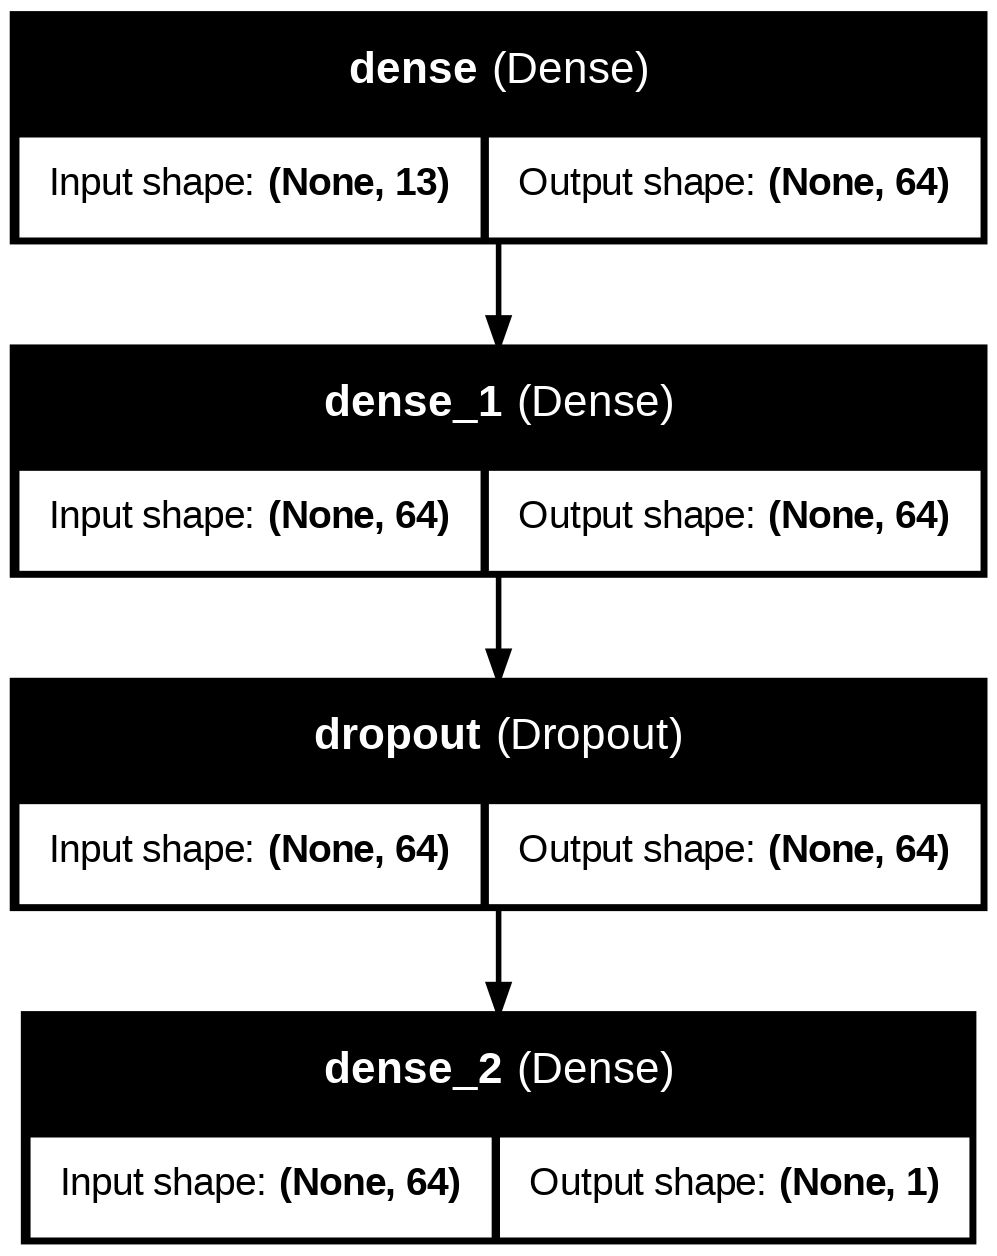

In [ ]:
# Visualize the model
plot_model(model, show_shapes=True, show_layer_names=True, to_file='model.png')
Image(retina=True, filename='model.png')

In [ ]:
history = model.fit(train_data, #X
                    train_targets, #Y
                    epochs = 100, # Rounds of training
                    batch_size=128, # Size of elements
                    validation_split= 0.25) # Validation split, as this model is very prone to overfitting

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - loss: 541.2148 - val_loss: 628.8353
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 483.6488 - val_loss: 553.3365
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 432.4361 - val_loss: 440.2264
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 307.7267 - val_loss: 287.7356
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 184.8636 - val_loss: 175.1276
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 120.1182 - val_loss: 126.7842
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 72.8435 - val_loss: 98.0900
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 62.4476 - val_loss: 82.4465
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 59.9492 - val_loss: 71.2124
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 52.6086 - val_loss: 62.6210
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 44.0628 - val_loss: 56.0954
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2

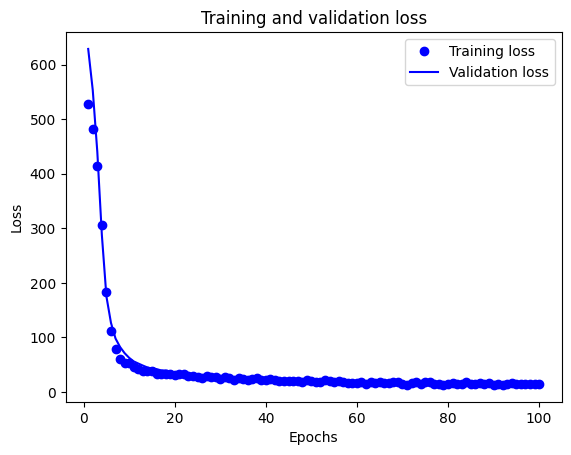

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# Evaluate on test set
model.evaluate(test_data, test_targets)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 14.3390


18.257919311523438

In [ ]:
# Predict the new values
model.predict(test_data)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


array([[ 8.390022],
       [17.904991],
       [20.803572],
       [31.033049],
       [24.639156],
       [17.741144],
       [26.949217],
       [21.80947 ],
       [18.543749],
       [20.58848 ],
       [15.889101],
       [16.351213],
       [16.25489 ],
       [41.404713],
       [17.647886],
       [19.814154],
       [27.063267],
       [22.114506],
       [17.95089 ],
       [26.972643],
       [11.613634],
       [14.808134],
       [20.197927],
       [15.39624 ],
       [21.731539],
       [22.667799],
       [30.419432],
       [29.575907],
       [10.634417],
       [21.694891],
       [19.40145 ],
       [14.080511],
       [33.522495],
       [25.289059],
       [16.190298],
       [ 8.111675],
       [13.982908],
       [17.400036],
       [20.938915],
       [26.454803],
       [28.463018],
       [28.122328],
       [15.102436],
       [40.13359 ],
       [30.025423],
       [22.856527],
       [25.386244],
       [16.69143 ],
       [22.867785],
       [22.288279],


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


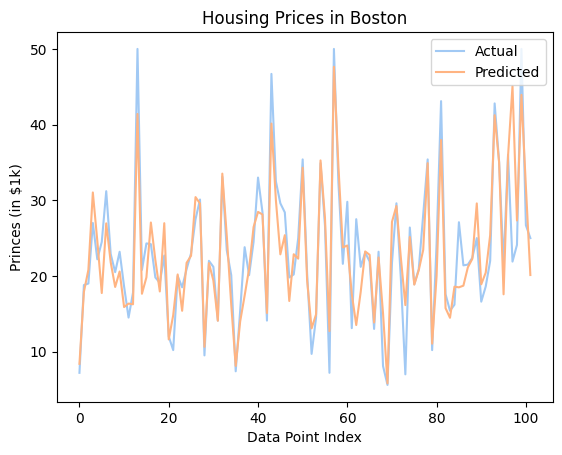

In [ ]:
import seaborn as sns

predictions = model.predict(test_data)

sns.set_palette("pastel")
plt.plot(test_targets, label="Actual", linestyle='-')
plt.plot(predictions, label="Predicted", linestyle='-')


plt.xlabel("Data Point Index")
plt.ylabel("Princes (in $1k)")
plt.title("Housing Prices in Boston")
plt.legend()

plt.show()